In [3]:
!pip install --upgrade pip setuptools wheel -i https://pypi.tuna.tsinghua.edu.cn/simple

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 4.7 MB/s  0:00:00
  Attempting uninstall: wheel
    Found existing installation: wheel 0.46.3
    Uninstalling wheel-0.46.3:
      Successfully uninstalled wheel-0.46.3
  Attempting uninstall: setuptools
    Found existing installation: setuptools 65.5.1
    Uninstalling setuptools-65.5.1:
      Successfully uninstalled setuptools-65.5.1━━━━━━━━━━━━━━━━━━ 1/2 [setuptools]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [setuptools]2 [setuptools]


In [5]:
# 安装和PyTorch3D兼容的旧版fvcore
!pip install fvcore==0.1.5.post20221221 iopath matplotlib ninja -i https://pypi.tuna.tsinghua.edu.cn/simple

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
  Using cached fvcore-0.1.5.post20221221.tar.gz (50 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61443 sha256=7db258fd80fa3910eace90c5d3ebc759ce674f4cc87edbad76ec40993dd5c8ab
  Stored in directory: /root/.cache/pip/wheels/a9/30/46/b7cb09b198d92063dc624e2a538b4d31eaa0629b56590c791c
  Created wheel for iopath: filename=iopath-0.1.10-py3-none-any.whl size=31596 sha256=8b2b54a9cb419989717fb55d9c172b7ef78096536d8ffcf1bb47e4e12a219772
  Stored in directory: /root/.cache/pip/wheels/34/08/79/f24d785c5011f876e8c7ae6fc636f91ad789da14b51e719c6a
Successfully built fvcore iopath
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [fvc

In [6]:
!pip install "git+https://gitee.com/hongwenzhang/pytorch3d.git" --no-build-isolation

Looking in indexes: https://mirrors.cloud.aliyuncs.com/pypi/simple
  Cloning https://gitee.com/hongwenzhang/pytorch3d.git to /tmp/pip-req-build-ob3teenw
  Running command git clone --filter=blob:none --quiet https://gitee.com/hongwenzhang/pytorch3d.git /tmp/pip-req-build-ob3teenw
  Resolved https://gitee.com/hongwenzhang/pytorch3d.git to commit b6a77ad7aaf41ed90fca80ce6a2bac3c462a7881
  Preparing metadata (pyproject.toml) ... done
  Created wheel for pytorch3d: filename=pytorch3d-0.7.9-cp311-cp311-linux_x86_64.whl size=64484441 sha256=330fa635fd4d06cb785cbda51ca2d927a1ffa883b042693bac90c5268b6e6236
  Stored in directory: /tmp/pip-ephem-wheel-cache-ycef_src/wheels/2d/8b/12/6e318153711ff74bb8bc1b6ef9e1f7fb0efd88402eace988f3
Successfully built pytorch3d


迭代步数: 299/300 | 总 Loss: 0.0179 | 剪影误差: 0.0141
[*] 已保存当前 3D 模型至: output_meshes/mesh_epoch_299.obj


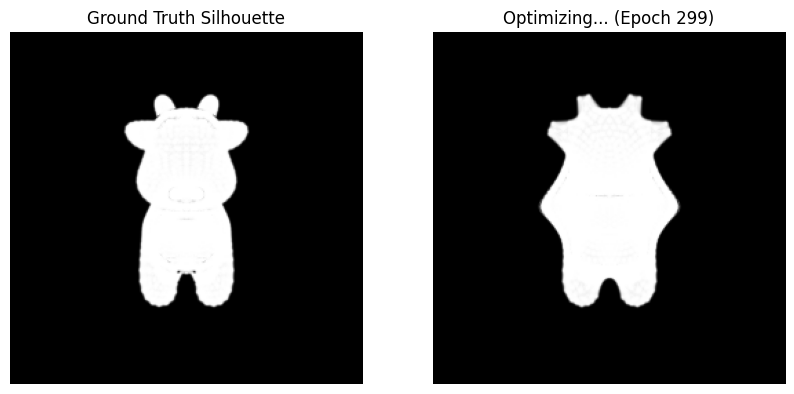

优化完成！所有中间状态的 .obj 文件已保存在 output_meshes 文件夹中。


In [8]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output 

import pytorch3d
# 引入 save_obj 用于保存 3D 模型
from pytorch3d.io import load_obj, save_obj
from pytorch3d.structures import Meshes
from pytorch3d.utils import ico_sphere
from pytorch3d.loss import mesh_edge_loss, mesh_laplacian_smoothing, mesh_normal_consistency
from pytorch3d.renderer import (
    look_at_view_transform, FoVPerspectiveCameras,
    RasterizationSettings, MeshRasterizer, SoftSilhouetteShader, BlendParams
)

# 确认设备
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"当前运行设备: {device}")
print(f"PyTorch3D 版本: {pytorch3d.__version__}")

# ---------------------------------------------------------
# 1. 直接读取助教打包好的本地模型文件
# ---------------------------------------------------------
obj_path = "cow.obj" 
if not os.path.exists(obj_path):
    raise FileNotFoundError("未找到 cow.obj，请确保代码文件与 obj 文件在同一目录下！")

# 准备目标数据与归一化处理
verts, faces, _ = load_obj(obj_path)
faces_idx = faces.verts_idx.to(device)
verts = verts.to(device)
verts = (verts - verts.mean(0)) / max(verts.abs().max(0)[0]) 
cow_mesh = Meshes(verts=[verts], faces=[faces_idx])

# ---------------------------------------------------------
# 2. 渲染管线与摄像机配置
# ---------------------------------------------------------
num_views = 20
cameras = FoVPerspectiveCameras(device=device, 
                                R=look_at_view_transform(2.7, torch.zeros(num_views), torch.linspace(-180, 180, num_views))[0], 
                                T=look_at_view_transform(2.7, torch.zeros(num_views), torch.linspace(-180, 180, num_views))[1])

rasterizer = MeshRasterizer(cameras=cameras, 
                            raster_settings=RasterizationSettings(image_size=256, blur_radius=np.log(1./1e-4 - 1.)*1e-4, faces_per_pixel=50))
shader = SoftSilhouetteShader(blend_params=BlendParams(sigma=1e-4, gamma=1e-4))

target_silhouette = shader(rasterizer(cow_mesh.extend(num_views)), cow_mesh.extend(num_views))[..., 3]

# ---------------------------------------------------------
# 3. 优化器初始化：从圆球开始
# ---------------------------------------------------------
src_mesh = ico_sphere(4, device)
deform_verts = torch.zeros_like(src_mesh.verts_packed(), requires_grad=True)
optimizer = torch.optim.SGD([deform_verts], lr=1.0, momentum=0.9)

# 创建保存中间结果的文件夹
output_dir = "output_meshes"
os.makedirs(output_dir, exist_ok=True)
print(f"中间模型将保存在目录: ./{output_dir}/")

# ---------------------------------------------------------
# 4. 可微渲染优化循环
# ---------------------------------------------------------
epochs = 300
for i in range(epochs):
    optimizer.zero_grad()
    
    # 依据当前计算出的偏移量，形变生成新的 Mesh
    new_src_mesh = src_mesh.offset_verts(deform_verts)
    
    # 渲染当前 Mesh 的 20 个视角剪影
    pred_silhouette = shader(rasterizer(new_src_mesh.extend(num_views)), new_src_mesh.extend(num_views))[..., 3]
    
    # 【核心损失】：均方误差 + 三大正则化惩罚
    loss_silhouette = ((pred_silhouette - target_silhouette) ** 2).mean()
    loss = loss_silhouette + \
           1.0 * mesh_laplacian_smoothing(new_src_mesh) + \
           0.1 * mesh_edge_loss(new_src_mesh) + \
           0.01 * mesh_normal_consistency(new_src_mesh)
    
    loss.backward()
    optimizer.step()

    # 可视化与模型保存逻辑：每 20 步执行一次
    if i % 20 == 0 or i == epochs - 1:
        clear_output(wait=True)
        print(f"迭代步数: {i:03d}/{epochs} | 总 Loss: {loss.item():.4f} | 剪影误差: {loss_silhouette.item():.4f}")
        
        # 提取当前网格的顶点和面，并保存为 .obj 文件
        # verts_list()[0] 和 faces_list()[0] 用于获取 batch 中第一个（也是唯一一个）网格的数据
        current_verts = new_src_mesh.verts_list()[0]
        current_faces = new_src_mesh.faces_list()[0]
        
        save_path = os.path.join(output_dir, f"mesh_epoch_{i:03d}.obj")
        save_obj(save_path, current_verts, current_faces)
        print(f"[*] 已保存当前 3D 模型至: {save_path}")
        
        # 刷新对比图
        fig, ax = plt.subplots(1, 2, figsize=(10, 5))
        
        ax[0].imshow(target_silhouette[0].cpu().numpy(), cmap='gray')
        ax[0].set_title("Ground Truth Silhouette")
        ax[0].axis("off")
        
        ax[1].imshow(pred_silhouette[0].detach().cpu().numpy(), cmap='gray')
        ax[1].set_title(f"Optimizing... (Epoch {i})")
        ax[1].axis("off")
        
        plt.show()

print(f"优化完成！所有中间状态的 .obj 文件已保存在 {output_dir} 文件夹中。")

In [1]:
!pip install --upgrade pip -i https://pypi.tuna.tsinghua.edu.cn/simple

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 2.7 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: pip
    Found existing installation: pip 23.3.2
    Uninstalling pip-23.3.2:
      Successfully uninstalled pip-23.3.2
